# Mérési notebook
---
# **1. mérési fázis**. A	Modellek tesztelése tanítás nélkül.

#### **Cél**: Modellek tesztelése saját adathalmazon, majd saját modell ötletek tesztelése
#### **Diplomamunka címe**: Fotográfiai témafelismerés neurális hálózatokkal nagy adathalmazon.
#### **Készítette**: Sándor Balázs - AZA6NL

## 3. modell **EfficientNet-B0** modell tanítás nélküli tesztelése

#### A  EfficientNet-B0@ImageNet1k modell tanítás nélküli futtatása a saját ImageNet180K adathalmaz Test részhalmazán. (teszt elemszám: 18k).


---



✅ 1. Telepítés + GPU ellenőrzés

In [ ]:
!pip install -q --upgrade pip
!pip install -q timm torchvision tqdm scikit-learn

import torch
if torch.cuda.is_available():
    print("✅ GPU aktív:", torch.cuda.get_device_name(0))
else:
    print("⚠️ Nincs GPU! Runtime > Change runtime type > GPU")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 77.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 200.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 220.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 180.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 168.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 212.1 MB/s eta 0:00:00
✅ GPU aktív: NVIDIA L4


✅ 2. Drive csatolás + ZIP kicsomagolás

In [ ]:
from google.colab import drive
import zipfile, os

drive.mount('/content/drive')

diploma_path = "/content/drive/MyDrive/diplomamunka"
zip_path = os.path.join(diploma_path, "imagenet_splitted_db.zip")
extract_path = "/content/imagenet_splitted_db"

os.makedirs(extract_path, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("📁 Kicsomagolva:", extract_path)


Mounted at /content/drive
📁 Kicsomagolva: /content/imagenet_splitted_db


✅ 3. Modell, adatbetöltés, predikció

In [ ]:
import torch.nn.functional as F
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader
from torchvision.models import EfficientNet_B0_Weights
import numpy as np
import time
from tqdm import tqdm

# Paraméterek
batch_size = 64
num_workers = 2
test_dir = "/content/imagenet_splitted_db/imagenet_splitted_db/test"

# Transzformáció
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Tesztadat
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

# Modell betöltés
weights = EfficientNet_B0_Weights.DEFAULT
model = models.efficientnet_b0(weights=weights)
model.eval().cuda()

# Predikciók
all_preds, all_probs, all_labels = [], [], []

start_time = time.perf_counter()

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Inference"):
        inputs = inputs.cuda()
        outputs = model(inputs)
        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

end_time = time.perf_counter()
inference_time = end_time - start_time


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 229MB/s]
Inference: 100%|██████████| 284/284 [00:28<00:00,  9.83it/s]


✅ 4. Metrikák számítása (helyes leképezéssel!)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, top_k_accuracy_score

# Leképezés
normalized_class_names = [name.replace("_", " ").lower() for name in test_dataset.classes]
imagenet_categories = weights.meta["categories"]
imagenet_name_to_index = {name.lower(): idx for idx, name in enumerate(imagenet_categories)}
imagenet_indices = [imagenet_name_to_index[name] for name in normalized_class_names]

y_probs = np.array(all_probs)
y_probs_subset = y_probs[:, imagenet_indices]

y_true = np.array(all_labels)
y_pred = np.argmax(y_probs_subset, axis=1)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
top5 = top_k_accuracy_score(y_true, y_probs_subset, k=5)

print(f"\n🔍 Vizsgálat eredményei (EfficientNet-B0 @ ImageNet1k, saját 114 osztály):")
print(f"✅ Top-1 Accuracy:  {accuracy:.4f}")
print(f"✅ Top-5 Accuracy:  {top5:.4f}")
print(f"🎯 Precision:       {precision:.4f}")
print(f"🎯 Recall:          {recall:.4f}")
print(f"🎯 F1-score:        {f1:.4f}")
print(f"⏱️ Inference time:  {inference_time:.2f} sec")



🔍 Vizsgálat eredményei (EfficientNet-B0 @ ImageNet1k, saját 114 osztály):
✅ Top-1 Accuracy:  0.4802
✅ Top-5 Accuracy:  0.8217
🎯 Precision:       0.4137
🎯 Recall:          0.4039
🎯 F1-score:        0.3829
⏱️ Inference time:  28.89 sec


✅ 5. Confusion Matrix, per-class metrikák, CSV export, gyenge osztályok

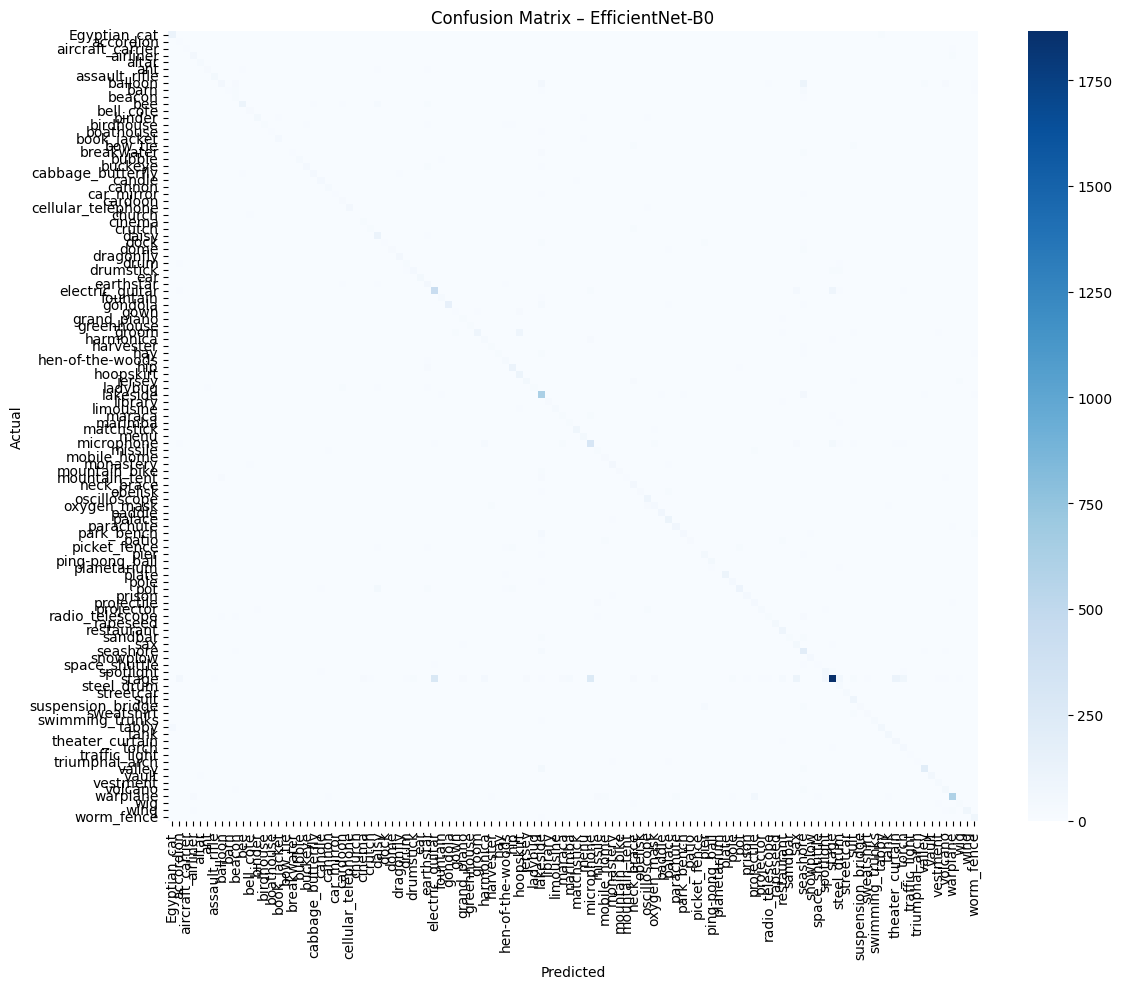


📋 Részletes metrikák osztályonként:

                    precision    recall  f1-score   support

      Egyptian_cat       0.67      0.79      0.73       145
         accordion       0.09      0.26      0.14        47
  aircraft_carrier       0.31      0.28      0.30        39
          airliner       0.47      0.65      0.54        80
             altar       0.38      0.51      0.43        59
               ant       0.30      0.23      0.26        95
     assault_rifle       0.45      0.51      0.47        91
           balloon       0.36      0.16      0.22       338
              barn       0.33      0.12      0.17       111
            beacon       0.16      0.32      0.21        62
               bee       0.72      0.50      0.59       212
         bell_cote       0.26      0.38      0.31        77
            binder       0.45      0.44      0.44       105
         birdhouse       0.55      0.15      0.23       116
         boathouse       0.23      0.30      0.26        43
 

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

# Osztálynevek
class_names = test_dataset.classes

# Confusion matrix
conf_mat = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(conf_mat, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – EfficientNet-B0")
plt.tight_layout()
plt.show()

# Részletes jelentés
print("\n📋 Részletes metrikák osztályonként:\n")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

# Export CSV-be
precision_per_class, recall_per_class, f1_per_class, _ = precision_recall_fscore_support(
    y_true, y_pred, zero_division=0
)

df_metrics = pd.DataFrame({
    "Class": class_names,
    "Precision": precision_per_class,
    "Recall": recall_per_class,
    "F1-score": f1_per_class,
})
df_metrics.to_csv("/content/efficientnet_b0_test_metrics.csv", index=False)
print("📁 Mentve: efficientnet_b0_test_metrics.csv")

# Gyenge osztályok
print("\n😢 Legrosszabbul teljesítő osztályok:")
print(df_metrics.sort_values("F1-score").head(10))


Kategória remapping ellenőrzés

In [ ]:
# --- 1. y_true / y_pred tartomány-ellenőrzés ---
print("✅ Index-tartomány ellenőrzés:")
print(f" - y_true: {np.min(y_true)} – {np.max(y_true)}")
print(f" - y_pred: {np.min(y_pred)} – {np.max(y_pred)}")
print(f" - y_probs_subset.shape: {y_probs_subset.shape}")

if np.max(y_true) >= len(class_names) or np.max(y_pred) >= len(class_names):
    print("⚠️ Figyelem: valamelyik index kilóg a 114 kategória tartományából!")
else:
    print("✅ Minden index a megfelelő tartományban van.")

print("\n📋 Kategória-párosítás ellenőrzés:")
print(f"{'Lokális index':<15} {'Mappanév (raw)':<30} {'Normalizált név':<30} {'ImageNet index':<15}")
print("-" * 95)
for i, (raw, norm, idx) in enumerate(zip(class_names, normalized_class_names, imagenet_indices)):
    print(f"{i:<15} {raw:<30} {norm:<30} {idx:<15}")


✅ Index-tartomány ellenőrzés:
 - y_true: 0 – 113
 - y_pred: 0 – 113
 - y_probs_subset.shape: (18172, 114)
✅ Minden index a megfelelő tartományban van.

📋 Kategória-párosítás ellenőrzés:
Lokális index   Mappanév (raw)                 Normalizált név                ImageNet index 
-----------------------------------------------------------------------------------------------
0               Egyptian_cat                   egyptian cat                   285            
1               accordion                      accordion                      401            
2               aircraft_carrier               aircraft carrier               403            
3               airliner                       airliner                       404            
4               altar                          altar                          406            
5               ant                            ant                            310            
6               assault_rifle                  assault rifle